### Initial setup

In [1]:
import torch
import matplotlib.pyplot as plt

In [7]:
names = []
with open('../02_ACLM/italian_names_dataset/italian_masculine_given_names.txt') as f:
    names.extend(f.read().lower().splitlines())
with open('../02_ACLM/italian_names_dataset/italian_feminine_given_names.txt') as f:
    names.extend(f.read().lower().splitlines())

In [9]:
chars = sorted(list(set(''.join(names))))
stoi = {s: i+1 for i, s in enumerate(chars)} # string to int
stoi['.'] = 0
stoi = {k: v for k, v in sorted(stoi.items(), key=lambda x: x[1])}
itos = {i: s for s, i in stoi.items()} # int to string

### Class configuration

In [10]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        self.weight.requires_grad = True
        self.bias.requires_grad = True

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight, self.bias] if self.bias is not None else [self.weight]

In [11]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / (xvar.sqrt() + self.eps) # normalized
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean # buffer update (mean)
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar # buffer update (variance)

        return self.out

In [12]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

### Training + Validation + Test split

In [85]:
def build_dataset(names, block_size):
    X, Y = [], []
    for name in names:
        context = [0] * block_size
        for ch in name + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
import torch.nn.functional as F
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names)) # 80% of the data for training
n2 = int(0.9 * len(names)) # 10% of the data for validation, 10% for testing

BLOCK_SIZE = 3

Xtr, Ytr = build_dataset(names[:n1], BLOCK_SIZE)
Xdev, Ydev = build_dataset(names[n1:n2], BLOCK_SIZE)
Xte, Yte = build_dataset(names[n2:], BLOCK_SIZE)

### MLP Configuration

In [121]:
EMBEDDING_DIM = 2
HIDDEN_NEURONS = 100
N_CHARS = len(stoi)

C = torch.randn((N_CHARS, EMBEDDING_DIM))
layers = [Linear(EMBEDDING_DIM * BLOCK_SIZE, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, N_CHARS)]

with torch.no_grad():
    layers[-1].weight *= 0.1 # less confident predictor after softmax
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # Kaiming for tanh

parameters = [p for layer in layers for p in layer.parameters() if p is not None]
for p in parameters:
    p.requires_grad = True

### Training

In [114]:
BATCH_SIZE = 200
lossi = []
lossi_idx = []
dev_lossi = []
dev_lossi_idx = []
ud = []
learning_rate = 10**(-0.7)
DECAY = 0.9999

EPOCH = 200 + 1

Xtr_len = Xtr.shape[0]

for e in range(EPOCH):
    perm = torch.randperm(Xtr_len)
    for i in range(0, Xtr_len, BATCH_SIZE):
        ix = perm[i:i + BATCH_SIZE]
        Xb, Yb = Xtr[ix], Ytr[ix]
        # forward pass
        emb = C[Xb]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        loss = F.cross_entropy(x, Yb)
        # backward pass
        for layer in layers:
            layer.out.retain_grad()
        for p in parameters:
            p.grad = None
        loss.backward()
        # update
        for p in parameters:
            p.data -= learning_rate * p.grad
        learning_rate *= DECAY
        # track
        lossi.append(loss.log10().item())
        lossi_idx.append(e*Xtr_len + min(Xtr_len, i + BATCH_SIZE))
        with torch.no_grad():
            ud.append([((learning_rate * p.grad).std() / p.data.std()).log10().item() for p in parameters])
    # dev loss a fine epoch
    with torch.no_grad():
        emb = C[Xdev]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        dev_loss = F.cross_entropy(x, Ydev)
    dev_lossi.append(dev_loss.log10().item())
    dev_lossi_idx.append(e * Xtr_len)
    if e % 10 == 0:
        print(f'EPOCH #{e:03}  train {loss.item():.4f}  dev {dev_loss.item():.4f}')

EPOCH #000  train 2.6668  dev 2.5744
EPOCH #010  train 2.1245  dev 2.3046
EPOCH #020  train 1.8889  dev 2.2322
EPOCH #030  train 2.2213  dev 2.1725
EPOCH #040  train 2.1661  dev 2.1565
EPOCH #050  train 1.9349  dev 2.1258
EPOCH #060  train 1.7662  dev 2.1186
EPOCH #070  train 2.0206  dev 2.1032
EPOCH #080  train 1.9995  dev 2.0676
EPOCH #090  train 1.8036  dev 2.0791
EPOCH #100  train 1.9778  dev 2.0611
EPOCH #110  train 1.5689  dev 2.0439
EPOCH #120  train 1.5035  dev 2.0488
EPOCH #130  train 1.8866  dev 2.0392
EPOCH #140  train 1.7971  dev 2.0307
EPOCH #150  train 1.7172  dev 2.0348
EPOCH #160  train 2.0112  dev 2.0270
EPOCH #170  train 1.8405  dev 2.0334
EPOCH #180  train 1.7439  dev 2.0280
EPOCH #190  train 1.7843  dev 2.0181
EPOCH #200  train 1.5269  dev 2.0174


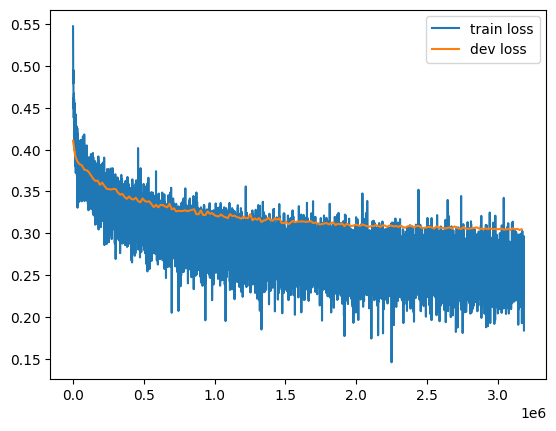

In [115]:
plt.plot(lossi_idx, lossi)
plt.plot(dev_lossi_idx, dev_lossi)
plt.legend(['train loss', 'dev loss'])
plt.show()

### Overfitting view

In [122]:
BATCH_SIZE = 200
lossi = []
lossi_idx = []
dev_lossi = []
dev_lossi_idx = []
ud = []
learning_rate = 10**(-0.5)
DECAY = 0.9999

EPOCH = 1_000 + 1

Xtr_len = Xtr.shape[0]

for e in range(EPOCH):
    perm = torch.randperm(Xtr_len)
    for i in range(0, Xtr_len, BATCH_SIZE):
        ix = perm[i:i + BATCH_SIZE]
        Xb, Yb = Xtr[ix], Ytr[ix]
        # forward pass
        emb = C[Xb]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        loss = F.cross_entropy(x, Yb)
        # backward pass
        for layer in layers:
            layer.out.retain_grad()
        for p in parameters:
            p.grad = None
        loss.backward()
        # update
        for p in parameters:
            p.data -= learning_rate * p.grad
        learning_rate *= DECAY
        # track
        lossi.append(loss.log10().item())
        lossi_idx.append(e*Xtr_len + min(Xtr_len, i + BATCH_SIZE))
        with torch.no_grad():
            ud.append([((learning_rate * p.grad).std() / p.data.std()).log10().item() for p in parameters])
    # dev loss a fine epoch
    with torch.no_grad():
        emb = C[Xdev]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        dev_loss = F.cross_entropy(x, Ydev)
    dev_lossi.append(dev_loss.log10().item())
    dev_lossi_idx.append(e * Xtr_len)
    if e % 50 == 0:
        print(f'EPOCH #{e:04}  train {loss.item():.4f}  dev {dev_loss.item():.4f}')

EPOCH #0000  train 2.6634  dev 2.6042
EPOCH #0050  train 1.5883  dev 2.1094
EPOCH #0100  train 1.9273  dev 2.0434
EPOCH #0150  train 1.6391  dev 2.0277
EPOCH #0200  train 1.5660  dev 2.0065
EPOCH #0250  train 1.6294  dev 1.9926
EPOCH #0300  train 1.4926  dev 1.9958
EPOCH #0350  train 1.6821  dev 1.9932
EPOCH #0400  train 1.4372  dev 1.9924
EPOCH #0450  train 1.8503  dev 1.9933
EPOCH #0500  train 1.4655  dev 1.9943
EPOCH #0550  train 1.4885  dev 1.9941
EPOCH #0600  train 1.5325  dev 1.9939
EPOCH #0650  train 1.4020  dev 1.9946
EPOCH #0700  train 1.5635  dev 1.9945
EPOCH #0750  train 1.4575  dev 1.9947
EPOCH #0800  train 1.7831  dev 1.9947
EPOCH #0850  train 1.4467  dev 1.9947
EPOCH #0900  train 1.4937  dev 1.9947
EPOCH #0950  train 1.7541  dev 1.9948
EPOCH #1000  train 1.7266  dev 1.9948


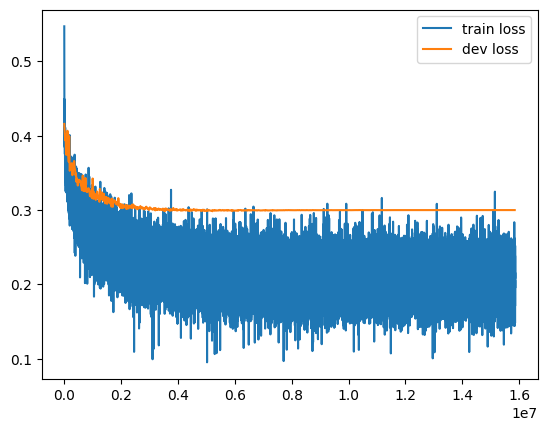

In [123]:
plt.plot(lossi_idx, lossi)
plt.plot(dev_lossi_idx, dev_lossi)
plt.legend(['train loss', 'dev loss'])
plt.show()